In [1]:
import torch, random
from statistics import mean
from cebmf_torch import cEBMF
import matplotlib.pyplot as plt
# ---- config
NUM_RUNS   =20
N, P       = 50, 40
NOISE_STD  = 1.0
MAXIT      = 50
TOL        = 1e-9   # numerical tolerance for strictness

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

def is_strictly_increasing(xs, tol=0.0001):
    # xs[t+1] > xs[t] + tol  for all t
    return all(xs[t+1] > xs[t] + tol for t in range(len(xs)-1))

def is_strictly_decreasing(xs, tol=0.0):
    # xs[t+1] < xs[t] - tol  for all t
    return all(xs[t+1] < xs[t] - tol for t in range(len(xs)-1))

def one_run(seed):
    # reproducibility
    random.seed(seed)
    torch.manual_seed(seed)

    # rank-1 signal + Gaussian noise
    u = torch.rand(N, device=device)
    v = torch.rand(P, device=device)
    Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

    model = cEBMF(data=Y, K=5, allow_backfitting=False)
    model.initialise_factors()
    model.fit(maxit=MAXIT)

    loss_hist = model.obj                       # your stored objective = negative ELBO
    return(loss_hist)
 


results=[]

for i in range(NUM_RUNS):
    results.append( one_run(i))
 

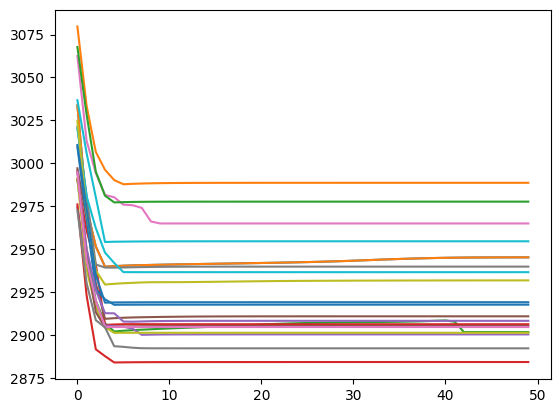

In [2]:
plt.plot(results[0])
for i in range(NUM_RUNS):
    plt.plot(results[i])

In [3]:
def is_strictly_increasing(xs, tol=0.1):
    # xs[t+1] > xs[t] + tol  for all t
    return all(xs[t+1] > xs[t] - tol for t in range(len(xs)-1))

In [4]:
is_strictly_increasing(results[0])

False

In [5]:
h=0

for i in range(NUM_RUNS):
    if (is_strictly_increasing(results[i], tol=0.005))== False:
        print(i)
        h=h+1



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [6]:
(results[6])

[3021.1840920365494,
 2981.244848750483,
 2941.0760529807526,
 2939.2861688709195,
 2939.260411464566,
 2939.3305193833517,
 2939.442106589341,
 2939.550086301105,
 2939.6368615210913,
 2939.7007641957175,
 2939.745611528968,
 2939.7761946018736,
 2939.796683689208,
 2939.810258575139,
 2939.8191896195967,
 2939.8250393582416,
 2939.8288600511146,
 2939.831350996746,
 2939.8329731249783,
 2939.834028688893,
 2939.834715246254,
 2939.8351616576433,
 2939.8354518639053,
 2939.8356404985843,
 2939.835763100997,
 2939.835842781457,
 2939.835894564575,
 2939.8359282167776,
 2939.8359500858955,
 2939.8359642975242,
 2939.8359735328645,
 2939.835979534358,
 2939.835983434353,
 2939.835985968707,
 2939.835987615617,
 2939.835988685833,
 2939.835989381294,
 2939.8359898332274,
 2939.8359901269064,
 2939.8359903177493,
 2939.835990441764,
 2939.8359905223524,
 2939.835990574722,
 2939.8359906087526,
 2939.835990630867,
 2939.835990645238,
 2939.835990654576,
 2939.835990660644,
 2939.83599066458